## Customer Churn

In [ ]:
# import kagglehub

# path = kagglehub.dataset_download("blastchar/telco-customer-churn")

# print("Path to dataset files:", path)

In [2]:
# importing model
import pandas as pd
import numpy as np

# importing visualization module
import matplotlib.pyplot as plt
import seaborn as sns

# importing sklearn
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# importing model
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# importing metrics -> for classification, were going to use acc, prec,...
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

# Load dataset

In [3]:
df = pd.read_csv("customer_churn.csv", delimiter=",")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df.shape

(7043, 21)

In [6]:
df.describe(include="all")

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,6531,2
top,3186-AJIEK,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,20.2,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


In [7]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)

C:\Users\nguye\AppData\Local\Temp\ipykernel_35384\617195598.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)


In [8]:
if "customerID" in df.columns:
    df = df.drop("customerID", axis=1)

In [9]:
df["Churn"] = df["Churn"].map({
    "Yes": 1,
    "No": 0
})

In [10]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

## Train Test Split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state= 42, test_size=0.2, stratify=y)

In [12]:
# split nums cols and Categorical cols
num_cols = X.select_dtypes(include= ["int64", "float64"]).columns.tolist()
cat_cols = X.select_dtypes(include= ["object"]).columns.tolist()

print("Number column:", num_cols)
print("Categorical columns:", cat_cols)

Number column: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [13]:
## Preprocessor

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown= 'ignore'), cat_cols)
])

In [16]:
## Evaluation Function

def evaluate(model_name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    pre = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    print(f"{model_name}")
    print(f"Accuracy: {acc}")
    print(f"Precision: {pre}")
    print(f"Recall: {rec}")
    print(f"F1 Score: {f1}")
    print("-"*20)

    return {
        "Model": model_name,
        "Accuracy": acc,
        "Precision": pre,
        "Recall" : rec,
        "F1 Score" : f1
    }

In [17]:
## Logistic model
log_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

log_model.fit(X_train, y_train)
y_pred_result = log_model.predict(X_test)

log_result = evaluate(
    "Logistic Regression",
    y_test,
    y_pred_result
)

Logistic Regression
Accuracy: 0.8055358410220014
Precision: 0.6572327044025157
Recall: 0.5588235294117647
F1 Score: 0.6040462427745664
--------------------


In [18]:
## Decision tree

tree_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(max_depth=5, random_state=42))
])

tree_model.fit(X_train, y_train)
y_pred_tree = tree_model.predict(X_test)

tree_results = evaluate(
    "Decision Tree",
    y_test,
    y_pred_tree
)

Decision Tree
Accuracy: 0.7984386089425124
Precision: 0.6347305389221557
Recall: 0.5668449197860963
F1 Score: 0.5988700564971752
--------------------


In [19]:
# Random Forest Classification

rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(n_estimators=200, random_state=42))
])

rf_model.fit(X_train, y_train)
y_pred_fr = tree_model.predict(X_test)

rf_result = evaluate(
    "Random Forest Classifier",
    y_test,
    y_pred_fr
)

Random Forest Classifier
Accuracy: 0.7984386089425124
Precision: 0.6347305389221557
Recall: 0.5668449197860963
F1 Score: 0.5988700564971752
--------------------


In [21]:
## Comparing models

results_df = pd.DataFrame([
    log_result,
    tree_results,
    rf_result
])

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.805536,0.657233,0.558824,0.604046
1,Decision Tree,0.798439,0.634731,0.566845,0.598870
2,Random Forest Classifier,0.798439,0.634731,0.566845,0.598870


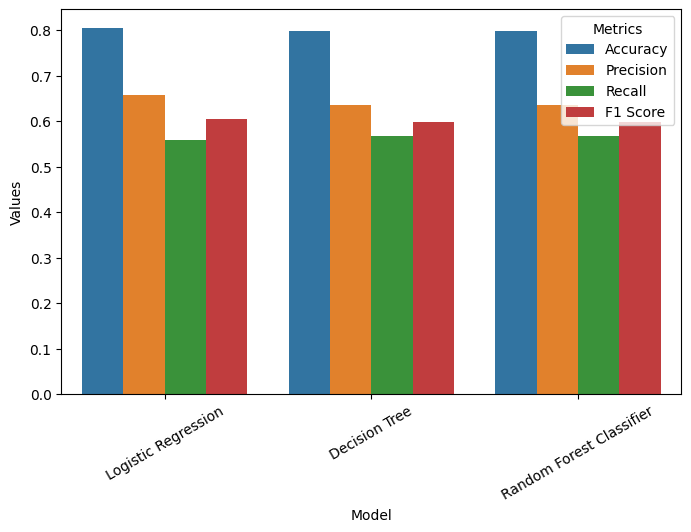

In [22]:
# visualize model after compairing

results_melted = results_df.melt(
    id_vars="Model",
    var_name="Metrics",
    value_name="Value",
)


plt.figure(figsize=(8, 5))
sns.barplot(data= results_melted, x= "Model", y= "Value", hue= "Metrics")
plt.ylabel("Values")
plt.xlabel("Model")
plt.xticks(rotation= 30)
plt.show()

In [ ]:
# ploting confusion matrix

cm = confusion_matrix(y_test, y_pred_result)

plt.figure(figsize= (8, 5))
sns.heatmap(cm, annot= True, fmt="d")
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [27]:
def gen_cm(model_name :str, y_true, y_pred, cmap = "Blues"):

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8, 5))
    sns.heatmap(cm, annot= True, fmt="d", cmap = cmap )
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

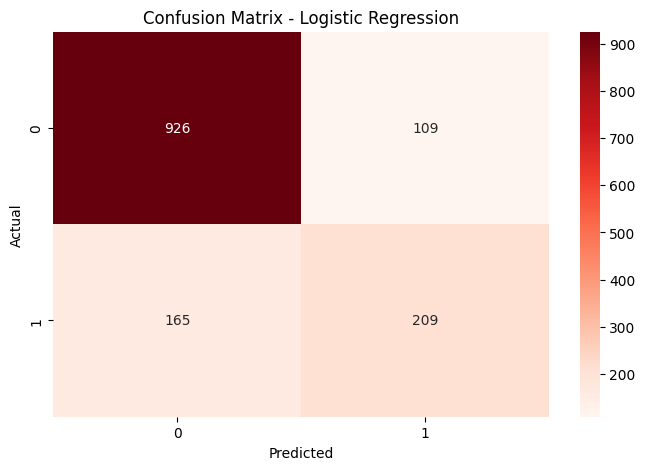

In [29]:
gen_cm("Logistic Regression", y_test, y_pred_result, "Reds")

In [31]:
print(classification_report(y_test, y_pred_result))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [33]:
# Testing
new_customer = {
    "gender": "Male",
    "SeniorCitizen": 0,
    "Partner": "Yes",
    "Dependents": "No",
    "tenure": 12,
    "PhoneService": "Yes",
    "MultipleLines": "No",
    "InternetService": "Fiber optic",
    "OnlineSecurity": "No",
    "OnlineBackup": "Yes",
    "DeviceProtection": "No",
    "TechSupport": "No",
    "StreamingTV": "Yes",
    "StreamingMovies": "No",
    "Contract": "Month-to-month",
    "PaperlessBilling": "Yes",
    "PaymentMethod": "Electronic check",
    "MonthlyCharges": 70.5,
    "TotalCharges": 850.2
}

new_df = pd.DataFrame([new_customer])
new_df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,Male,0,Yes,No,12,Yes,No,Fiber optic,No,Yes,No,No,Yes,No,Month-to-month,Yes,Electronic check,70.5,850.2


In [34]:
prediction = log_model.predict(new_df)

In [35]:
prediction

array([1])

In [36]:
prob = log_model.predict_proba(new_df)
prob

array([[0.29928905, 0.70071095]])